### SVM (서포트 벡터 머신)

- 패턴 인식, 자료 분석 등을 위한 지도 학습 모델
- 회귀, 분류 모두 존재
- 회귀선에서 일정량만큼 떨어진 부분에 영역을 생성하여 영역 안팎에 데이터들의 가중치를 변화

- parameter
    
    - `C`
        - default: 1.0
        - 규제 강도의 역수
        - margin 영역의 크기
    
    - `kernel`
        - default: `rbf`
        - 실제 데이터가 선형이 아닌 경우 커널 함수를 이용하여 데이터를 고차원 공간으로 매핑
            - 직선으로 구분
        - `linear`: 선형 SVM
        - `poly`: 다항식 커널
        - `rbf`: 가우시안 커널 (가장 많이 사용)
    
    - `gamma`
        - `kernel`의 개수
        - `kernel`이 `linear`가 아닌 경우 사용
        - `gamma`가 크다면 경계가 복잡해짐 (과적합 위험)
        - `gamma`가 작다면 경계가 유연해짐 (일반화 위험)
    
    - `degree`
        - default : 3
        - 다항식 kernel에서 차수
    
    - `probability`
        - default : False
        - 확률을 출력할 것인가? → True인 경우에는 predict_proba() 사용 가능
            - True로 설정 시 추가적인 계산으로 인해 속도가 느려질 수 있다.

- 속성

    - `support_`
        - 서포트 벡터 경계선에 딱 붙어있는 데이터의 인덱스 값

    - `support_vector_`
        - support_는 위치 값이라면 support_vector_는 실제 데이터

    - `n_support_`
        - 클래스(column)별 서포트 벡터의 개수

    - `coef_`
        - 결정 계수 (linear일 때만 사용 가능)

- 메서드

    - decision_function()
        - 결정 함수의 값 (margin과의 거리)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv('../data/classification.csv')
df.head()

,age,interest,success
0,23.657801,18.859917,0.0
1,22.573729,17.969223,0.0
2,32.553424,29.463651,0.0
3,6.718035,25.704665,1.0
4,14.401919,16.770856,0.0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   interest  297 non-null    float64
 2   success   297 non-null    float64
dtypes: float64(3)
memory usage: 7.1 KB


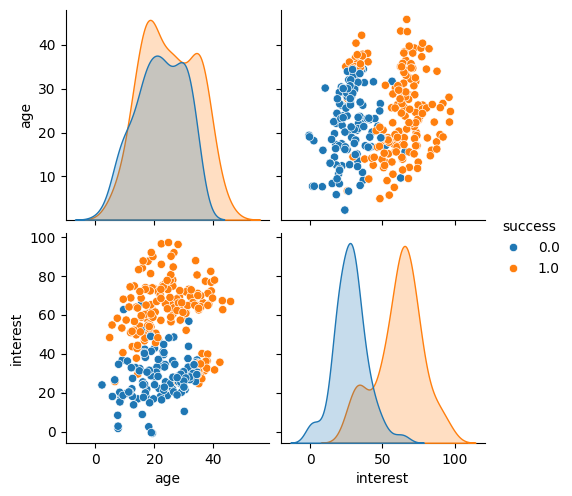

In [ ]:
# 데이터 클래스 분포를 그래프로 확인

sns.pairplot(
    data = df,
    hue = 'success'
)

In [ ]:
X = df.drop('success', axis = 1)
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
svc = SVC()
svc_2 = SVC(C=0.1)

In [ ]:
svc.fit(X_train, y_train)
svc_2.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
pred = svc.predict(X_test)
pred2 = svc_2.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, pred)
acc_2 = accuracy_score(y_test, pred2)

prc = precision_score(y_test, pred)
prc_2 = precision_score(y_test, pred2)

rcll = recall_score(y_test, pred)
rcll_2 = recall_score(y_test, pred2)

f1 = f1_score(y_test, pred)
f1_2 = f1_score(y_test, pred2)

In [ ]:
print('정확도: ', round(acc, 4), round(acc_2, 4))
print('정밀도: ', round(prc, 4), round(prc_2, 4))
print('재현율: ', round(rcll, 4), round(rcll_2, 4))
print('f1 score: ', round(f1, 4), round(f1_2, 4))

정확도:  0.9 0.9
정밀도:  0.9821 0.9821
재현율:  0.873 0.873
f1 score:  0.9244 0.9244


In [ ]:
# 분류 분석 선형 SVC 모델을 로드

from sklearn.svm import LinearSVC

C의 값이 0.1인 경우 support_vector의 개수는 169입니다.
C의 값이 100인 경우 support_vector의 개수는 126입니다.


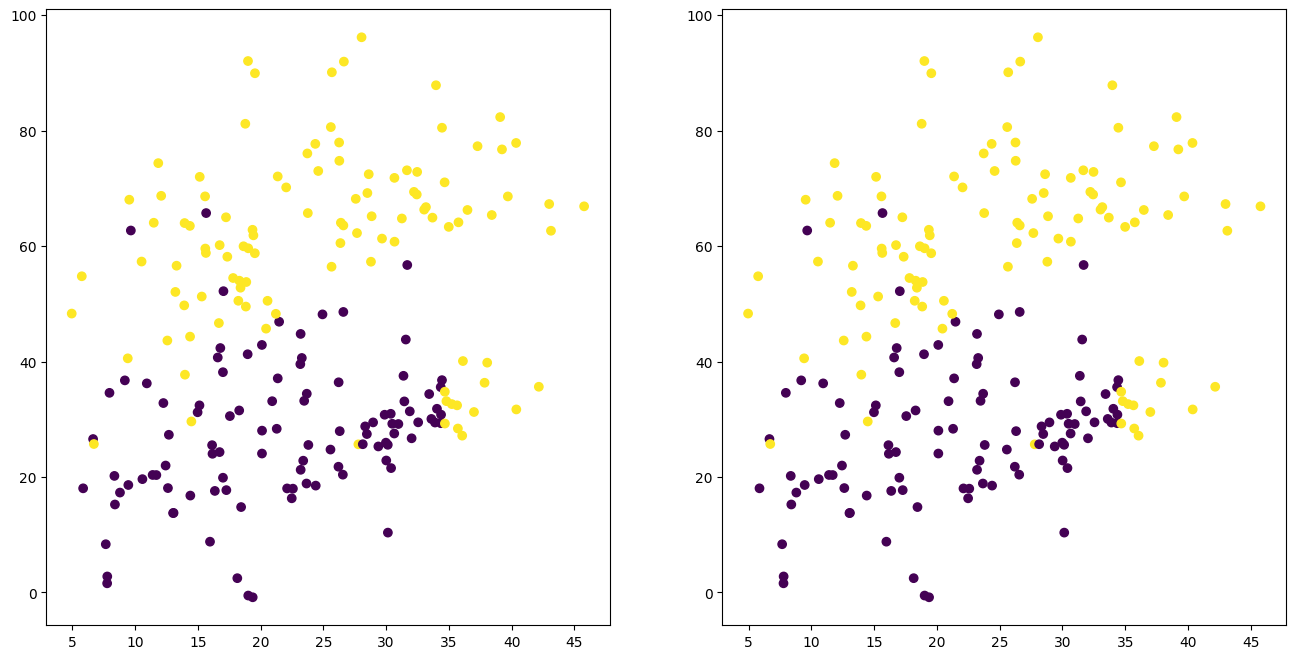

In [ ]:
plt.figure(figsize = (16, 8))
for i, c in enumerate([0.1, 100]):
    
    model = LinearSVC(C = c, random_state=42)
    model.fit(X_train, y_train)
    
    decision = model.decision_function(X_train)

    support_vector_indices = np.where( np.abs(decision) <= 1 + 1e-15 )[0]

    support_vector = X_train.values[support_vector_indices]

    print(f'C의 값이 {c}인 경우 support_vector의 개수는 {len(support_vector)}입니다.')

    plt.subplot(1, 2, i+1)
    plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c = y_train.values)

### SVR (서포트 벡터 머신 - 회귀)

- 입실론 튜브 안의 데이터들을 오차로 보지 않는다.
- 튜브 밖의 데이터에만 패널티 부여

- parameter
    - kernel
        - linear
            - 사용가능 매개변수: C, epsilron
        - rbf
            - 사용가능 매개변수: C, epsilron, gamma
        - poly
            - 사용가능 매개변수: C, epsilron, gamma, degre

    - epsilron
        - 오차 허용 폭
    
    - gamma
        - 기울기의 변화량

    - max_iter
        - 기본값 : None
        - 최적화가 될때까지 최대 반복 횟수
            - 수치가 불안정한 경우 필요
            - svm 모델에서는 시간이 오래 걸리기 때문제 가급적 사용
    
    - tol
        - 기본값 : 0.001
        - 수렴의 판단 기준

- 속성
    - dual_coef_
        - 쌍대 문제의 알파 값들
    - coef_
        - 회귀 계수

In [13]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
boston = pd.read_csv('../csv/boston.csv')

In [15]:
X = boston.drop('Price', axis = 1)
y = boston['Price']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify= X['CHAS']
)

In [17]:
svr_rbf = SVR(kernel = 'rbf', gamma = 'auto', epsilon = 0.1)
svr_lin = SVR(kernel = 'linear')
svr_poly = SVR(kernel = 'poly', gamma = 'auto')

In [18]:
# svr_rbf.fit(X_train, y_train)
# svr_lin.fit(X_train, y_train)
# svr_poly.fit(X_train, y_train)

In [ ]:
x = np.sort(5 * np.random.rand(40, 1), axis = 0)

In [22]:
y = np.sin(x).ravel()
    # ravel: 1차원으로 변경

y

array([ 0.01783832,  0.16764103,  0.67964255,  0.70409697,  0.7600641 ,
        0.8270752 ,  0.99292453,  0.96424994,  0.90747416,  0.88498729,
        0.85526652,  0.81751577,  0.80957125,  0.80805574,  0.70035977,
        0.60550042,  0.48258893,  0.37775613,  0.1048298 ,  0.03699818,
       -0.01706386, -0.16426269, -0.20701194, -0.21806234, -0.23277344,
       -0.26589519, -0.34913617, -0.38262155, -0.38672906, -0.42061911,
       -0.54046407, -0.55814927, -0.56833191, -0.7898115 , -0.83282334,
       -0.89305011, -0.98653818, -0.99747361, -0.99639503, -0.98176733])

In [23]:
# 이대로면 너무 정직한 데이터가 됨(싸인 회귀선으로 전부 나타낼 수 있음)
# 노이즈 추가

y[::5] += 3 * (0.5 - np.random.rand(8))

In [24]:
svr_rbf.fit(x, y)
svr_lin.fit(x, y)
svr_poly.fit(x, y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [25]:
pred_rbf = svr_rbf.predict(x)
pred_lin = svr_lin.predict(x)
pred_poly = svr_poly.predict(x)

In [26]:
index = ['RBF', 'Linear', 'Poly']
cols = ['MSE', 'R2']

result = pd.DataFrame(index = index, columns = cols)
result

,MSE,R2
RBF,NaN,NaN
Linear,NaN,NaN
Poly,NaN,NaN


In [28]:
preds = [pred_rbf, pred_lin, pred_poly]

for pred, idx in zip(preds, index):
    mse = mean_squared_error(y, pred)
    r2 = r2_score(y, pred)

    result.loc[idx, 'MSE'] = round(mse, 2)
    result.loc[idx, 'R2'] = round(r2*100, 2)

result

,MSE,R2
RBF,0.18,68.72
Linear,0.39,34.04
Poly,0.28,52.56
